In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "prototype" / "src"))

from src.generators import generate_gift_recommendation
from src.model_config import get_available_models
from src.test_samples import get_test_profiles
from src.utils import load_env_from_repo_root

# Load .env file from repository root
load_env_from_repo_root(".env", override=True)

In [2]:
# # API_KEY="NsZEHgAXqIM66qVU" # fill this with the API Key from deployment setting

# # Initialize the OpenAI client with the vLLM API endpoint and your API key.
# client = OpenAI(
#     base_url="http://89.169.109.103:8000/v1/",
#     api_key=os.getenv("SANTA_SELF_HOSTED_1_API_KEY"),
# )

# completion = client.chat.completions.create(
#     model="deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
#     messages=[
#         {
#             "role": "user",
#             "content": """Hello!"""
#         }
#     ],
#     # temperature=0.8
# )

# print(completion.to_json())

In [3]:
"""Test self-hosted DeepSeek model for gift recommendation evaluation."""

from pathlib import Path

from src.data_scheme import KidProfile
from src.utils import load_env_from_repo_root

# Load environment variables
load_env_from_repo_root()

# Set up self-hosted model environment variables (if not already set)
# These would typically be in your .env file:
# SANTA_SELF_HOSTED_1_BASE_URL=http://89.169.109.103:8000/v1/
# SANTA_SELF_HOSTED_1_API_KEY=your_api_key_here
# SANTA_SELF_HOSTED_1_MODEL=deepseek-ai/DeepSeek-R1-Distill-Llama-8B
# SANTA_SELF_HOSTED_1_NAME=self-hosted-deepseek-r1

# Or set them programmatically for testing:
# if not os.getenv("SANTA_SELF_HOSTED_1_BASE_URL"):
#     os.environ["SANTA_SELF_HOSTED_1_BASE_URL"] = "http://89.169.109.103:8000/v1/"
#     os.environ["SANTA_SELF_HOSTED_1_API_KEY"] = os.getenv("SANTA_API_KEY", "")
#     os.environ["SANTA_SELF_HOSTED_1_MODEL"] = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
#     os.environ["SANTA_SELF_HOSTED_1_NAME"] = "self-hosted-deepseek-r1"


def test_self_hosted_deepseek():
    """Test gift recommendation generation with self-hosted DeepSeek model."""
    print("🔍 Testing self-hosted DeepSeek model for gift recommendations...\n")

    # Get available models (including self-hosted)
    models = get_available_models(include_self_hosted=True)

    # Create a test kid profile
    test_kid = KidProfile(name="Emma", age=7, wishlist=["doll", "art supplies", "books"])

    print("📝 Test Kid Profile:")
    print(f"   Name: {test_kid.name}")
    print(f"   Age: {test_kid.age}")
    print(f"   Wishlist: {', '.join(test_kid.wishlist)}\n")

    # Generate gift recommendation
    for model in models:
        print(model)

        try:
            recommendation, metrics = generate_gift_recommendation(
                llm_client=model.client, kid_profile=test_kid, temperature=0.8, max_tokens=300
            )

            print("✅ Success!\n")
            print("📊 Metrics:")
            print(f"   Latency: {metrics.get('latency_ms', 0):.2f} ms")
            print(f"   Tokens in: {metrics.get('tokens_in', 'N/A')}")
            print(f"   Tokens out: {metrics.get('tokens_out', 'N/A')}")
            print(f"   Model: {metrics.get('model', 'N/A')}\n")

            print("🎁 Recommended Gifts:")
            for i, gift in enumerate(recommendation.gifts, 1):
                print(f"   {i}. {gift}")

            print("\n💭 Rationale:")
            print(f"   {recommendation.rationale}\n")

        except Exception as e:
            print(f"❌ Error generating recommendation: {str(e)}")
            raise


test_self_hosted_deepseek()

🔍 Testing self-hosted DeepSeek model for gift recommendations...

📝 Test Kid Profile:
   Name: Emma
   Age: 7
   Wishlist: doll, art supplies, books

✅ Success!

📊 Metrics:
   Latency: 883.97 ms
   Tokens in: 222
   Tokens out: 105
   Model: deepseek-ai/DeepSeek-R1-Distill-Llama-8B

🎁 Recommended Gifts:
   1. Personalized Emma Doll
   2. Art Supply Backpack
   3. Interactive Storytime Book

💭 Rationale:
   The Personalized Emma Doll is a unique twist on her wish for a doll, making it feel special and one-of-a-kind. The Art Supply Backpack is practical and aligns with her love for creating, keeping her art materials organized and ready for adventures. The Interactive Storytime Book combines her interests in storytelling and learning, offering hours of engaging content tailored to her age.

✅ Success!

📊 Metrics:
   Latency: 438.11 ms
   Tokens in: 222
   Tokens out: 106
   Model: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B

🎁 Recommended Gifts:
   1. Puzzle Cubes! Fun for all ages, perfec

# Benchmark

In [4]:
from src.benchmark_llm import run_benchmark_suite

models = get_available_models(
    include_openai=True, include_token_factory=True, include_self_hosted=True
)
profiles = get_test_profiles()
print(profiles)

[KidProfile(id='e3430eab-491c-4337-a2d2-d87b25cd738a', name='Emma', age=7, wishlist=['doll', 'art supplies', 'books']), KidProfile(id='8e90ce27-dab9-4b26-9c4e-05c2155d8408', name='Lucas', age=10, wishlist=['LEGO set', 'video games', 'bicycle']), KidProfile(id='1b8bb5f2-5e2b-4267-9385-48c32d3bc23b', name='Sophia', age=5, wishlist=['princess dress', 'stuffed animals']), KidProfile(id='82d1c3e0-f7d8-45c2-be62-6c255d7190d9', name='Noah', age=12, wishlist=['basketball', 'headphones', 'science kit'])]


In [5]:
import pandas as pd
from src.benchmark_llm import results_to_dataframe

result_frames = []

for concurrency in [1, 5, 10, 20]:
    results = run_benchmark_suite(models, profiles, concurrency=concurrency)
    result_frames.append(results_to_dataframe(results, concurrency=concurrency))

df = pd.concat(result_frames, ignore_index=True)
df

Starting benchmark suite with 6 models...
Using 4 test profiles
Concurrency level: 1

[1/6] Benchmarking gpt-4o-mini...
  ✓ Completed: 4/4 successful
[2/6] Benchmarking openai-gpt-3.5-turbo...
  ✓ Completed: 4/4 successful
[3/6] Benchmarking tf/gpt-oss-20b...
  ✓ Completed: 4/4 successful
[4/6] Benchmarking tf/DeepSeek-R1-0528...
  ✓ Completed: 4/4 successful
[5/6] Benchmarking santa-deepseek-r1-llama-8b...
  ✓ Completed: 4/4 successful
[6/6] Benchmarking santa-deepseek-r1-qwen-1d5b...
  ✓ Completed: 4/4 successful
                    model_name  latency_p50_ms  latency_p95_ms  \
0                  gpt-4o-mini          5326.0          7502.0   
1         openai-gpt-3.5-turbo          1134.0          1166.0   
2               tf/gpt-oss-20b          1290.0          1318.0   
3          tf/DeepSeek-R1-0528          5158.0          5324.0   
4   santa-deepseek-r1-llama-8b           857.0          1103.0   
5  santa-deepseek-r1-qwen-1d5b           487.0           655.0   

   latency_p99_m

,model_name,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_tokens_per_sec,tokens_in_avg,tokens_out_avg,success_rate,total_requests,successful_requests,cost_per_1m_in,cost_per_1m_out,cost_per_1m_in_throughput_based,cost_per_1m_out_throughput_based,cost_1m_requests,cost_1m_requests_throughput_based,concurrency
0,gpt-4o-mini,5326.0,7502.0,7502.0,111.0,220.00,122.50,1.0,4,4,0.15,0.60,NaN,NaN,106.0,NaN,1
1,openai-gpt-3.5-turbo,1134.0,1166.0,1166.0,387.0,224.00,89.50,1.0,4,4,1.50,2.00,NaN,NaN,514.0,NaN,1
2,tf/gpt-oss-20b,1290.0,1318.0,1318.0,250.0,282.00,276.75,1.0,4,4,0.15,0.60,NaN,NaN,208.0,NaN,1
3,tf/DeepSeek-R1-0528,5158.0,5324.0,5324.0,63.0,226.25,85.50,1.0,4,4,0.80,2.40,NaN,NaN,385.0,NaN,1
4,santa-deepseek-r1-llama-8b,857.0,1103.0,1103.0,452.0,222.00,108.75,1.0,4,4,3.30,6.79,2.60,2.60,1466.0,858.00,1
5,santa-deepseek-r1-qwen-1d5b,487.0,655.0,655.0,602.0,222.50,106.50,1.0,4,4,1.70,3.55,1.95,1.95,754.0,639.60,1
6,gpt-4o-mini,2730.0,4175.0,4175.0,539.0,220.00,123.75,1.0,4,4,0.15,0.60,NaN,NaN,107.0,NaN,5
7,openai-gpt-3.5-turbo,1067.0,1091.0,1091.0,913.0,224.00,87.75,1.0,4,4,1.50,2.00,NaN,NaN,510.0,NaN,5
8,tf/gpt-oss-20b,1283.0,1356.0,1356.0,959.0,282.00,280.75,1.0,4,4,0.15,0.60,NaN,NaN,210.0,NaN,5
9,tf/DeepSeek-R1-0528,4586.0,5121.0,5121.0,320.0,226.25,115.25,1.0,4,4,0.80,2.40,NaN,NaN,457.0,NaN,5


## Plots

/var/folders/pb/tn1_xgrn17qfr6nn7gsbz1c40000gn/T/ipykernel_38023/243760324.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


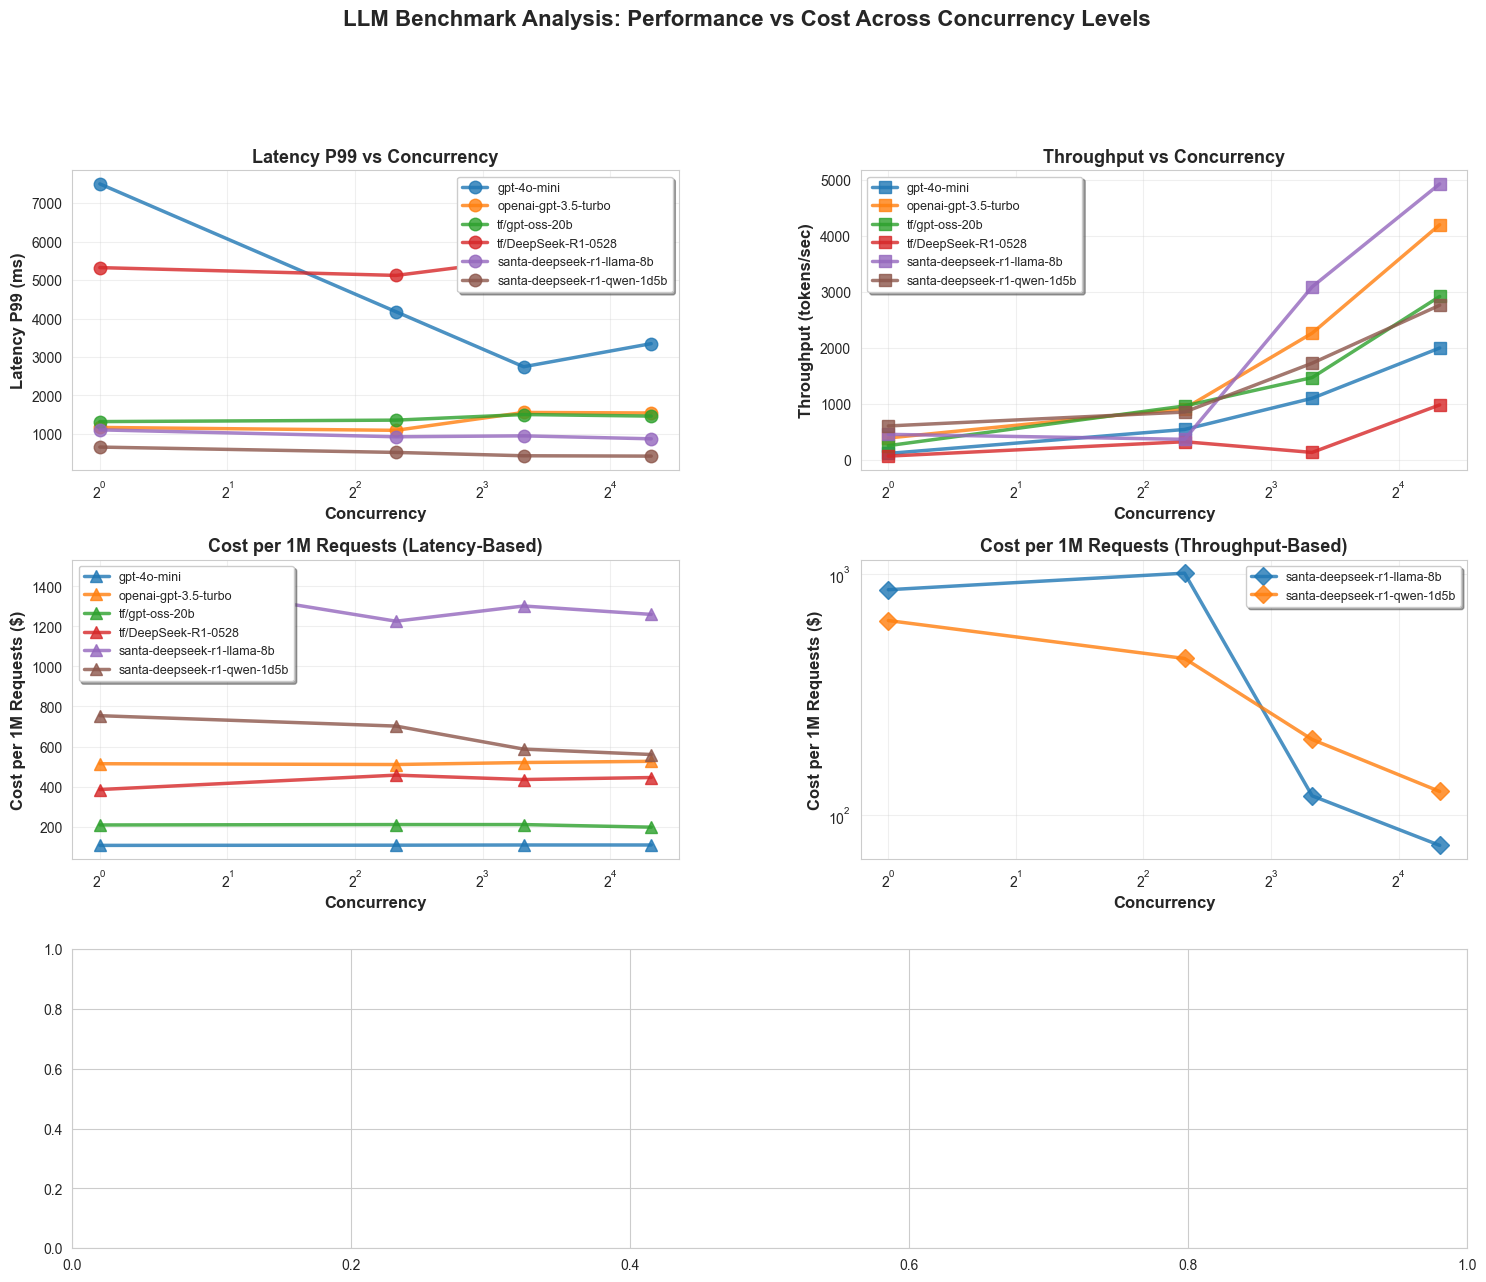


DETAILED ANALYSIS

📊 Cost Efficiency Analysis (Throughput-Based):
--------------------------------------------------------------------------------

santa-deepseek-r1-llama-8b:
  Best throughput: 4927.0 tok/s at concurrency=20
  Best cost: $75 per 1M requests at concurrency=20
  Latency P99 at best cost: 870.0 ms

santa-deepseek-r1-qwen-1d5b:
  Best throughput: 2759.0 tok/s at concurrency=20
  Best cost: $126 per 1M requests at concurrency=20
  Latency P99 at best cost: 420.0 ms


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 12)

# Assuming df is your combined DataFrame with all concurrency levels
# If not, combine: df = pd.concat(result_frames, ignore_index=True)

# Create comprehensive analysis plots
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Latency P99 vs Concurrency
ax1 = fig.add_subplot(gs[0, 0])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    ax1.plot(
        model_data["concurrency"],
        model_data["latency_p99_ms"],
        marker="o",
        label=model,
        linewidth=2.5,
        markersize=9,
        alpha=0.8,
    )

ax1.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax1.set_ylabel("Latency P99 (ms)", fontsize=12, fontweight="bold")
ax1.set_title("Latency P99 vs Concurrency", fontsize=13, fontweight="bold")
ax1.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xscale("log", base=2)

# 2. Throughput vs Concurrency
ax2 = fig.add_subplot(gs[0, 1])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    ax2.plot(
        model_data["concurrency"],
        model_data["throughput_tokens_per_sec"],
        marker="s",
        label=model,
        linewidth=2.5,
        markersize=9,
        alpha=0.8,
    )

ax2.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax2.set_ylabel("Throughput (tokens/sec)", fontsize=12, fontweight="bold")
ax2.set_title("Throughput vs Concurrency", fontsize=13, fontweight="bold")
ax2.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xscale("log", base=2)

# 3. Cost per 1M Requests (Latency-Based) vs Concurrency
ax3 = fig.add_subplot(gs[1, 0])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    ax3.plot(
        model_data["concurrency"],
        model_data["cost_1m_requests"],
        marker="^",
        label=model,
        linewidth=2.5,
        markersize=9,
        alpha=0.8,
    )

ax3.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax3.set_ylabel("Cost per 1M Requests ($)", fontsize=12, fontweight="bold")
ax3.set_title("Cost per 1M Requests (Latency-Based)", fontsize=13, fontweight="bold")
ax3.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xscale("log", base=2)

# 4. Cost per 1M Requests (Throughput-Based) vs Concurrency
ax4 = fig.add_subplot(gs[1, 1])
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    # Filter out NaN and zero values for better visualization
    valid_data = model_data[model_data["cost_1m_requests_throughput_based"].notna()]
    if not valid_data.empty:
        # Show actual values, not rounded zeros
        ax4.plot(
            valid_data["concurrency"],
            valid_data["cost_1m_requests_throughput_based"],
            marker="D",
            label=model,
            linewidth=2.5,
            markersize=9,
            alpha=0.8,
        )
        # Add annotation for zero values explaining they're < $0.50
        zero_data = model_data[
            (model_data["cost_1m_requests_throughput_based"] == 0.0)
            | (model_data["cost_1m_requests_throughput_based"].isna())
        ]
        if not zero_data.empty:
            for _, row in zero_data.iterrows():
                ax4.annotate(
                    "< $0.50", xy=(row["concurrency"], 50), fontsize=8, alpha=0.6, ha="center"
                )

ax4.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
ax4.set_ylabel("Cost per 1M Requests ($)", fontsize=12, fontweight="bold")
ax4.set_title("Cost per 1M Requests (Throughput-Based)", fontsize=13, fontweight="bold")
ax4.legend(loc="best", frameon=True, shadow=True, fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xscale("log", base=2)
ax4.set_yscale("log")  # Log scale to show the dramatic improvement

# 5. santa-deepseek-r1: Latency vs Throughput Cost Comparison
ax5 = fig.add_subplot(gs[2, :])
santa_data = df[df["model_name"] == "santa-deepseek-r1"].sort_values("concurrency")
if not santa_data.empty:
    ax5_twin = ax5.twinx()

    # Latency-based cost (left axis)
    line1 = ax5.plot(
        santa_data["concurrency"],
        santa_data["cost_1m_requests"],
        marker="o",
        label="Latency-Based Cost",
        linewidth=3,
        markersize=11,
        color="red",
        alpha=0.8,
    )

    # Throughput-based cost (left axis, but use different scale)
    valid_throughput = santa_data[santa_data["cost_1m_requests_throughput_based"].notna()]
    line2 = ax5.plot(
        valid_throughput["concurrency"],
        valid_throughput["cost_1m_requests_throughput_based"],
        marker="s",
        label="Throughput-Based Cost",
        linewidth=3,
        markersize=11,
        color="green",
        alpha=0.8,
    )

    # Throughput on right axis
    line3 = ax5_twin.plot(
        santa_data["concurrency"],
        santa_data["throughput_tokens_per_sec"],
        marker="^",
        label="Throughput (tokens/sec)",
        linewidth=2,
        markersize=9,
        color="blue",
        alpha=0.6,
        linestyle="--",
    )

    ax5.set_xlabel("Concurrency", fontsize=12, fontweight="bold")
    ax5.set_ylabel("Cost per 1M Requests ($)", fontsize=12, fontweight="bold", color="black")
    ax5_twin.set_ylabel("Throughput (tokens/sec)", fontsize=12, fontweight="bold", color="blue")
    ax5.set_title(
        "santa-deepseek-r1: Cost Comparison & Throughput Scaling", fontsize=14, fontweight="bold"
    )
    ax5.set_xscale("log", base=2)
    ax5.grid(True, alpha=0.3)

    # Combine legends
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax5.legend(lines, labels, loc="upper right", frameon=True, shadow=True)

plt.suptitle(
    "LLM Benchmark Analysis: Performance vs Cost Across Concurrency Levels",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "=" * 80)
print("DETAILED ANALYSIS")
print("=" * 80)

# Cost efficiency analysis
print("\n📊 Cost Efficiency Analysis (Throughput-Based):")
print("-" * 80)
for model in df["model_name"].unique():
    model_data = df[df["model_name"] == model].sort_values("concurrency")
    best_throughput = model_data.loc[model_data["throughput_tokens_per_sec"].idxmax()]
    best_cost = model_data[
        model_data["cost_1m_requests_throughput_based"].notna()
        & (model_data["cost_1m_requests_throughput_based"] > 0)
    ]

    if not best_cost.empty:
        best_cost_row = best_cost.loc[best_cost["cost_1m_requests_throughput_based"].idxmin()]
        print(f"\n{model}:")
        print(
            f"  Best throughput: {best_throughput['throughput_tokens_per_sec']:.1f} tok/s at concurrency={best_throughput['concurrency']}"
        )
        if not best_cost.empty:
            print(
                f"  Best cost: ${best_cost_row['cost_1m_requests_throughput_based']:.0f} per 1M requests at concurrency={best_cost_row['concurrency']}"
            )
            print(f"  Latency P99 at best cost: {best_cost_row['latency_p99_ms']:.1f} ms")